In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import umap 
import hdbscan
from pathlib import Path
import re 
from collections import defaultdict

In [2]:
import sys 
import os
sys.path.append(os.path.abspath('..'))
from scripts.image_embedding import ImageEmbedding 

In [3]:
scores_df = pd.read_csv('../data/processed/image_scores.csv')
scores_df.head()

,article_id,filename,decision,reason,noise_score,best_noise_prompt,image_path
0,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/8c566cffe64413c...
1,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/b7309d22a23a406...
2,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/deb2b33ba7ff621...
3,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/uploads/2025/03/25/Bl...
4,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/0137037746b37d7...


In [3]:
scores_df= scores_df.rename(columns={"article_id": "id"})

In [4]:
scores_df.head()

,id,filename,decision,reason,noise_score,best_noise_prompt,image_path
0,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/8c566cffe64413c...
1,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/b7309d22a23a406...
2,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/deb2b33ba7ff621...
3,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/uploads/2025/03/25/Bl...
4,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,NaN,discard,disallowed_extension,NaN,NaN,https://i.guim.co.uk/img/media/0137037746b37d7...


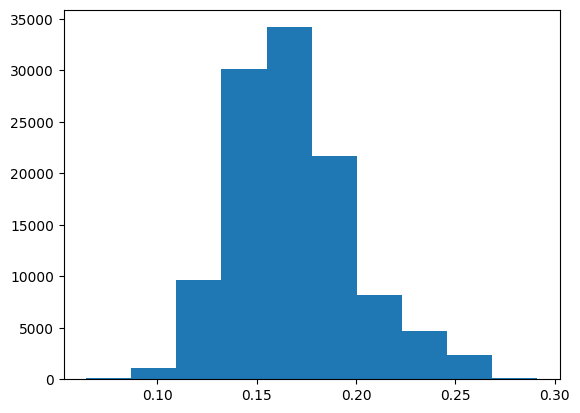

In [5]:
scores = scores_df[~scores_df['noise_score'].isna()]['noise_score']
plt.hist(scores)
plt.show()

In [4]:
df = pd.read_csv('../data/articles/final_AI_articles.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date
0,0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23
1,1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23
2,2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23
3,3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23
4,4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23


In [5]:
image_folder = Path('../data/processed/images_filtered')
pattern = re.compile(r"article_(.+?)_img_\d+\.[^.]+$", re.IGNORECASE)
image_map = defaultdict(list)
total_files = 0 
image_ids = []
for p in image_folder.iterdir():
    if p.is_file():
        total_files+=1 
        image_ids.append(str(p.name))
    match = pattern.match(p.name)
    if match:
        article_id = match.group(1)
        image_map[article_id].append(str(p.name))
df['final_images'] = df['id'].map(image_map)
df['final_images'] = df['final_images'].apply(lambda x: x if isinstance(x, list) else [])

In [6]:
total_files

153922

In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,url,error,title,text,top_image,images,id,indexed_date,media_name,media_url,publish_date,final_images
0,0,0,https://www.theguardian.com/technology/2025/de...,NaN,"Elon Musk, AI and the antichrist: the biggest ...","Hello, and welcome to TechScape. I’m your host...",https://i.guim.co.uk/img/media/deb2b33ba7ff621...,['https://i.guim.co.uk/img/media/deb2b33ba7ff6...,ca9eabe38bc978f50dce094319512165cad6ff8072ec37...,2025-12-23 20:26:44.681968+00:00,theguardian.com,theguardian.com,2025-12-23,[]
1,1,1,https://theconversation.com/how-can-canada-bec...,NaN,How can Canada become a global AI powerhouse? ...,Artificial intelligence is everywhere. In fact...,https://images.theconversation.com/files/70923...,"['data:image/gif;base64,R0lGODlhAQABAAD/ACwAAA...",d219ab84d8d98f17fd7d5abb20cee560e007ae14c0de6c...,2025-12-23 22:32:17.716034+00:00,theconversation.com,theconversation.com,2025-12-23,[]
2,2,2,https://www.cnbc.com/2025/12/23/ai-cost-effici...,NaN,The next AI pivot will be toward efficiency an...,"Kelly, who was also general counsel at Faceboo...",https://image.cnbcfm.com/api/v1/image/10817571...,['https://image.cnbcfm.com/api/v1/image/108213...,883df3997e09f2234edf2f2877d7c149d627976763be5d...,2025-12-23 19:17:47.972258+00:00,cnbc.com,cnbc.com,2025-12-23,[]
3,3,3,https://www.businessinsider.com/how-ai-transfo...,NaN,How AI Is Transforming the Workplace Faster Th...,AI is changing everything from what type of wo...,https://i.insider.com/694ae36a832e0ef1ead6bfbe...,['https://www.businessinsider.com/public/asset...,76a0a35549b802213cc653e25036aa5999fcd2e89d6ab3...,2025-12-23 20:22:34.590390+00:00,businessinsider.com,businessinsider.com,2025-12-23,[]
4,4,4,https://www.sandiegouniontribune.com/2025/12/2...,NaN,UC San Diego eyes campuswide AI coordinating s...,As institutions across the world establish app...,https://www.sandiegouniontribune.com/wp-conten...,['https://www.sandiegouniontribune.com/wp-cont...,19d73b7cd0a23f961ea3aae6d1554c62b004aac1a4a6c7...,2025-12-24 05:22:29.307373+00:00,sandiegouniontribune.com,sandiegouniontribune.com,2025-12-23,[article_19d73b7cd0a23f961ea3aae6d1554c62b004a...


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36320 entries, 0 to 36319
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  36320 non-null  int64  
 1   Unnamed: 0    36320 non-null  int64  
 2   url           36320 non-null  str    
 3   error         0 non-null      float64
 4   title         36154 non-null  str    
 5   text          36149 non-null  str    
 6   top_image     36154 non-null  str    
 7   images        36320 non-null  str    
 8   id            36320 non-null  str    
 9   indexed_date  36320 non-null  str    
 10  media_name    36320 non-null  str    
 11  media_url     36320 non-null  str    
 12  publish_date  36320 non-null  str    
 13  final_images  36320 non-null  object 
dtypes: float64(1), int64(2), object(1), str(10)
memory usage: 3.9+ MB


In [16]:
df[df['final_images'].str.len()>0].shape

(13020, 14)

In [7]:
no_image_df = pd.read_csv('../data/processed/no_image_articles.csv')
no_image_df.shape

(23134, 1)

In [12]:
embeddings1 = np.load('../data/processed/embeddings/image_embeddings.npy')
emb_image_ids = pd.read_csv('../data/processed/embeddings/image_ids.csv')

In [20]:
emb_image_ids.head()

,article_id,filename
0,d757b9b03d849d26400b15541078242ecb335600a9d3aa...,article_d757b9b03d849d26400b15541078242ecb3356...
1,d757b9b03d849d26400b15541078242ecb335600a9d3aa...,article_d757b9b03d849d26400b15541078242ecb3356...
2,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...
3,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...
4,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...


In [9]:
emb_ids = np.array(emb_image_ids['filename'])
image_ids = np.array(image_ids)
remaining_ids = np.setdiff1d(image_ids, emb_ids)

In [14]:
np.save('remaining_ids.npy', np.array(remaining_ids))

In [8]:
remaining_ids = np.load('remaining_ids.npy')
len(remaining_ids)

43597

In [53]:
remaining_ids[0]

np.str_('article_0004df4e857ae90e866604e551991fb407b1100d9af43846735f9c797b0211ba_img_0.jpg')

In [9]:
img_folder = "../data/processed/images_filtered"
output_path = "/Users/tanayapravinjoshi/Projects/MultimodalResearchProject/data/processed/embeddings"
file_name = "image_embeddings2.npy"
csv_name = "image_ids2.csv"

In [10]:
emb_obj = ImageEmbedding()
emb_obj.main(remaining_ids, img_folder, output_path, file_name, csv_name)

Found 43597 images


Embedding: 100%|██████████| 682/682 [10:14:47<00:00, 54.09s/it]    


Length of embeddings list:  682
Embeddings matrix: <class 'numpy.ndarray'>
Saved (43597, 768) embeddings → /Users/tanayapravinjoshi/Projects/MultimodalResearchProject/data/processed/embeddings


In [13]:
embeddings1.shape

(110325, 768)

In [15]:
embeddings2 = np.load('../data/processed/embeddings/image_embeddings2.npy')
image_ids2 = pd.read_csv('../data/processed/embeddings/image_ids2.csv')
embeddings2.shape


(43597, 768)

In [16]:
embeddings = np.vstack([embeddings1, embeddings2])
embeddings.shape

(153922, 768)

In [17]:
image_ids_all = pd.concat([emb_image_ids, image_ids2], ignore_index=True)
image_ids_all.shape

(153922, 2)

In [18]:
np.save("../data/processed/embeddings/embeddings_all.npy", embeddings)
image_ids_all.to_csv("../data/processed/embeddings/all_image_ids.csv", index=False)

# Clustering

In [2]:
embeddings = np.load("../data/processed/embeddings/embeddings_all.npy")
image_ids_all = pd.read_csv("../data/processed/embeddings/all_image_ids.csv")

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [9]:
for n in [10, 20, 30, 50]:
    reduced = umap.UMAP(n_components=n, low_memory=True).fit_transform(embeddings)
    labels = KMeans(n_clusters=100, random_state=42, n_init=10).fit_predict(reduced)
    score = silhouette_score(reduced, labels, sample_size=10000)
    print(f"n_components={n:>3} | silhouette={score:.3f}")

/Users/tanayapravinjoshi/Projects/MultimodalResearchProject/venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


n_components= 10 | silhouette=0.168
n_components= 20 | silhouette=0.148
n_components= 30 | silhouette=0.114
n_components= 50 | silhouette=0.133


In [6]:
reducer_10 = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)
embeddings_10 = reducer_10.fit_transform(embeddings)

/Users/tanayapravinjoshi/Projects/MultimodalResearchProject/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/tanayapravinjoshi/Projects/MultimodalResearchProject/venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/tanayapravinjoshi/Projects/MultimodalResearchProject/venv/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


In [7]:
embeddings_10.shape

(153922, 10)

In [8]:
from sklearn.metrics import silhouette_score
for k in [20, 30, 50, 75, 100]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(embeddings_10)
    score = silhouette_score(embeddings_10, labels, sample_size=10000)
    print(f"k={k:>4} | silhouette={score:.3f}")

k=  20 | silhouette=0.123
k=  30 | silhouette=0.138
k=  50 | silhouette=0.143
k=  75 | silhouette=0.173
k= 100 | silhouette=0.183


In [10]:
for k in [150, 200, 250, 300, 350]:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(embeddings_10)
    score = silhouette_score(embeddings_10, labels, sample_size=10000)
    print(f"k={k:>4} | silhouette={score:.3f}")

k= 150 | silhouette=0.222
k= 200 | silhouette=0.236
k= 250 | silhouette=0.267
k= 300 | silhouette=0.289
k= 350 | silhouette=0.314


In [11]:
kmeans = KMeans(n_clusters=300, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings_10)
image_ids_all["cluster"] = labels

In [12]:
image_ids_all["cluster"].value_counts()

cluster
131    5440
295    5431
12     5421
2      4292
99     4219
       ... 
35      104
280      84
294      71
282      64
195      60
Name: count, Length: 300, dtype: int64

In [13]:
from sklearn.metrics import pairwise_distances

In [17]:
representatives = {}
for c in range(300):
    mask = labels == c
    cluster_points = embeddings_10[mask]
    centroid = kmeans.cluster_centers_[c]
    distances = pairwise_distances([centroid], cluster_points)[0]
    top_5 = np.argsort(distances)[:5]
    original_indices = np.where(mask)[0][top_5]
    representatives[c] = image_ids_all.iloc[original_indices]["filename"].tolist()

In [20]:
representatives[0]

['article_5874fa35eabd8d7d89f1d5f283b83b18c50349517422a92e79359ba51f45ea77_img_23.jpg',
 'article_6e3600383f55efc7b8bb95f1f3dad260b378a5458e763911d2d07abb778214be_img_25.jpg',
 'article_40012524da5a3d0d3a184525cabde8632eca8e60579880bc386b69055183ae3d_img_23.jpg',
 'article_fa9acbbd174da268738207f7802e4024693170e25c19c24c364bfe25b9118116_img_26.jpg',
 'article_7da8e1647f8b48f95a2be41731dd534bd9860a9aa3b9334fd05fa5e6423a364d_img_25.jpg']

In [21]:
representatives[131]

['article_3ba82a46df0d914e43802e8a61c83cd35ac5bbac254d4e6d3c9452a5aef4e5ca_img_2.jpg',
 'article_acf4bb5da2dcd1c557b51c163b9020561dbda5347378e02ba36135c56f76b99e_img_0.jpg',
 'article_1f3ba9e49198161d1e02f99e01c24271f2bdee46eb966cb1adf91fc0c71d5b34_img_5.jpg',
 'article_8f8f8e97f55557042c4373b01001b85409712c509c13e7242b411dbc8fdc5353_img_0.jpg',
 'article_de15acbde65c1adc6a89dbc3fbc8640987ffed2f8378b8b75f13d0949a1cd291_img_32.jpg']

In [22]:
representatives[295]

['article_e991329d0778e0ce3d531d9dd1fcca1d06ac629c8b865d9e4390b940f03775fa_img_3.jpg',
 'article_2ad66b01c833743563594d7d3cd32073af9c4fe0c14deff3ffc63e7719f9fcc2_img_24.jpg',
 'article_3d96823d75411f660a3583ccbeb95e3f6f227e72d05b9ee7bddc6a88904a5497_img_21.jpg',
 'article_9895b5edf0e317a0a0a5b11e638c398566d8d3ea7d9506a1758b6620f0794e3f_img_25.jpg',
 'article_a0947ce309134553ddc922e647be0fc088d2e4ae33525e3f848c020d2952551c_img_2.jpg']

In [23]:
representatives[12]

['article_c1dcf7a42edd321963a22ad440b672197239946b1edd9558fece79ec0eb5e6d3_img_9.jpg',
 'article_9e653804fc9a3daffb9fb11565b59ba14d0d5bd4eb52f861d2e880637b1ff4d2_img_15.jpg',
 'article_9e653804fc9a3daffb9fb11565b59ba14d0d5bd4eb52f861d2e880637b1ff4d2_img_4.jpg',
 'article_13218573bface3b5f5dbdbe2c819805afa914664d828e6d8f9becdba3e30b07b_img_5.jpg',
 'article_ac21a70bf3d342904b28029fa2b99d14ef14884f888f936b4fd576c83da2c95d_img_48.jpg']

In [24]:
image_ids_all.head()

,article_id,filename,cluster
0,d757b9b03d849d26400b15541078242ecb335600a9d3aa...,article_d757b9b03d849d26400b15541078242ecb3356...,134
1,d757b9b03d849d26400b15541078242ecb335600a9d3aa...,article_d757b9b03d849d26400b15541078242ecb3356...,241
2,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...,118
3,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...,172
4,4152f7e826af50782a5826bf46f9099313e1085a3d7402...,article_4152f7e826af50782a5826bf46f9099313e108...,118


In [25]:
image_ids_all.to_csv('cluster_assignments.csv', index=False)